In [24]:
%load_ext autoreload
%autoreload 2

import os
import torchio as tio

# pra usar cpu, descomentar linha abaixo
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import nibabel as nib

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, models, Input, Model

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import gc
import seaborn as sns

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from PIL import Image
import tempfile
from math import ceil
import random
from tensorflow.keras import backend as K

#import wandb

import utils.processamento_dados as proc_dados
import utils.metricas_e_visualizacao as met_vil

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [26]:
from tensorflow.keras import mixed_precision

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Evita uso excessivo de memória
        print("GPU habilitada com sucesso!")
        print("Memory Growth habilitado para a GPU")
    except RuntimeError as e:
        print(e)

mixed_precision.set_global_policy("mixed_float16")

tf.get_logger().setLevel('ERROR')

GPU habilitada com sucesso!
Memory Growth habilitado para a GPU


In [27]:
# FUNÇÕES

def create_model_3d(input_shape, n_classes):
    inputs = Input(shape=input_shape)  # (D, H, W, C)

    # Camada 1
    x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 2
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 3
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # # Camada 4
    # x = layers.Conv3D(32, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    # x = layers.BatchNormalization()(x)
    # x = layers.LeakyReLU(negative_slope=0.3)(x)
    # # x = layers.MaxPooling3D(pool_size=(2, 2, 2), padding='same')(x)
    # x = layers.Dropout(0.3)(x)

    # Flatten e densas
    x = layers.Flatten()(x)

    x = layers.Dense(16, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model

In [28]:
# Definindo caminhos
dir_base = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn"

train_dir = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/train'
val_dir = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/validation'
results_dir_base = f'{dir_base}/OASIS/OASIS_NORMALIZED_MR2/results/ruidos_binary'
os.makedirs(results_dir_base, exist_ok=True)

results_dir = results_dir_base

transformations = ['noise']

In [29]:
# transform_name = None

# for item in transformations:
#     results_dir = f"{results_dir_base}/test_{item}"
#     if (not os.path.exists(results_dir)) or ((os.path.exists(results_dir) and len(os.listdir(results_dir)) < 3)):
#         os.makedirs(results_dir, exist_ok=True)
#         print(f"pasta test_{item} criada")
#         transform_name = item
#         break

In [30]:
# Nome das classes
oasis_class_names = ['0.0', '0.5', '1.0']
used_class_names = [0, 1]

n_oasis_classes = len(oasis_class_names)

train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
    train_dir, 
    oasis_class_names, 
    augment=True,
    augmentation_factor=3
)

print(f"N treino: {len(train_paths)}")

Passo 1: Coletando lista de arquivos...
Total de 492 imagens planejadas (incluindo aumentos).
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 492 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/492...
Processado 100/492...
Processado 150/492...
Processado 200/492...
Processado 250/492...
Processado 300/492...
Processado 350/492...
Processado 400/492...
Processado 450/492...
Passo 4: Carregamento concluído.
N treino: 492


In [31]:
# # Crie uma pasta específica para esta saída massiva
# pdf_reports_dir = os.path.join(results_dir, "relatorios_10_pessoas")

# # Chame a nova função
# met_vil.generate_axial_pdf_reports_no_prediction(
#     images=train_images,
#     true_labels_onehot=train_labels,
#     class_names=adni_class_names,
#     output_dir=pdf_reports_dir,
#     max_samples=100
# )

In [32]:
val_images, val_labels, val_paths, _ = proc_dados.load_nifti_data_balanced_preallocated(
    val_dir, 
    oasis_class_names, 
    augment=False
)

print(f"N validatio antes: {len(val_paths)}")

val_images, test_images, val_labels, test_labels, val_paths, test_paths = train_test_split(
    val_images, 
    val_labels, 
    val_paths, 
    train_size=0.6, 
    test_size=0.4, 
    random_state=42
)

print(f"N validation depois: {len(val_paths)}")
print(f"N teste: {len(test_paths)}")

Passo 1: Coletando lista de arquivos...
Total de 69 imagens planejadas (incluindo aumentos).
Passo 2: Determinando o shape da imagem...
Shape detectado: (156, 195, 160). Alocando memória para 69 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/69...
Passo 4: Carregamento concluído.
N validatio antes: 69
N validation depois: 41
N teste: 28


In [33]:
# Compila model
model = create_model_3d(train_images[2].shape, 2)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['binary_accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 156, 195, 160,  │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 156, 195, 160,  │           112 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 156, 195, 160,  │            16 │
│ (BatchNormalization)            │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 156, 195, 160,  │             0 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_3             │ (None, 52, 65, 54, 4)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 52, 65, 54, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_4 (Conv3D)               │ (None, 52, 65, 54, 8)  │           872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 52, 65, 54, 8)  │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 52, 65, 54, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_4             │ (None, 18, 22, 18, 8)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 18, 22, 18, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_5 (Conv3D)               │ (None, 18, 22, 18, 16) │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 18, 22, 18, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 18, 22, 18, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_5             │ (None, 6, 8, 6, 16)    │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 8, 6, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │        73,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             

 Total params: 78,410 (306.29 KB)

 Trainable params: 78,322 (305.95 KB)

 Non-trainable params: 88 (352.00 B)

In [34]:
batch_size = 10
steps_per_epoch = len(train_paths) // batch_size
validation_steps = len(val_paths) // batch_size

train_generator = proc_dados.nifti_data_generator_3d(train_images, train_labels, batch_size)
val_generator = proc_dados.nifti_data_generator_3d(val_images, val_labels, batch_size)

epochs = 100

new_model_name_ker = f"binary_classifier_noise_{epochs}_epochs_batch_{batch_size}_{n_oasis_classes}_classes.keras"

# Parar caso fique {patience} épocas sem melhora
early_stopping = EarlyStopping(
    monitor='val_loss',     
    patience=30,                 
    verbose=1
)

# # Defina o nome do arquivo para salvar o melhor modelo
model_checkpoint_callback = ModelCheckpoint(
    filepath=os.path.join(results_dir, new_model_name_ker),    
    monitor='val_binary_accuracy',
    save_best_only=True, 
    mode='max', 
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1)

log_path = os.path.join(results_dir, 'log_treino_ruido.csv')

csv_log = CSVLogger(log_path, append=False)

In [35]:
# print(f"Iniciando treinamento do modelo {new_model_name_ker} para classes {n_oasis_classes}")

# Treinamento
history = model.fit(
    train_generator,
    epochs=epochs,
    verbose=1,
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[model_checkpoint_callback, reduce_lr, csv_log, early_stopping]
)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 51s 619ms/step - binary_accuracy: 0.5776 - loss: 1.4753 - val_binary_accuracy: 0.3500 - val_loss: 1.3011 - learning_rate: 5.0000e-04
Epoch 2/100


2026-01-08 16:27:26.676715: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 4s:

  %reduce-window.259 = f32[2,52,65,54,4]{4,3,2,1,0} reduce-window(f32[2,156,195,160,4]{4,3,2,1,0} %broadcast.247, f32[] %constant.248), window={size=1x3x3x3x1 stride=1x3x3x3x1 pad=0_0x0_0x0_0x1_1x0_0}, to_apply=%region_1.255, metadata={op_type="AvgPool3D" op_name="functional_1_1/average_pooling3d_3_1/AvgPool3D"}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-01-08 16:27:29.952809: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 7.277486623s
Constant folding an instr

49/49 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - binary_accuracy: 0.6027 - loss: 1.3891 - val_binary_accuracy: 0.4000 - val_loss: 1.1638 - learning_rate: 5.0000e-04
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - binary_accuracy: 0.6598 - loss: 1.2320 - val_binary_accuracy: 0.5161 - val_loss: 1.1462 - learning_rate: 5.0000e-04
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - binary_accuracy: 0.6390 - loss: 1.2024 - val_binary_accuracy: 0.6750 - val_loss: 1.1054 - learning_rate: 5.0000e-04
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - binary_accuracy: 0.6950 - loss: 1.1050 - val_binary_accuracy: 0.7500 - val_loss: 1.0556 - learning_rate: 5.0000e-04
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - binary_accuracy: 0.6888 - loss: 1.1050 - val_binary_accuracy: 0.6129 - val_loss: 1.0819 - learning_rate: 5.0000e-04
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - binary_accuracy: 0.6846 - loss: 1.0598 - val_binary_accuracy: 0.6250 - val_loss: 1.0054 - learning_rate: 5.0000e-0

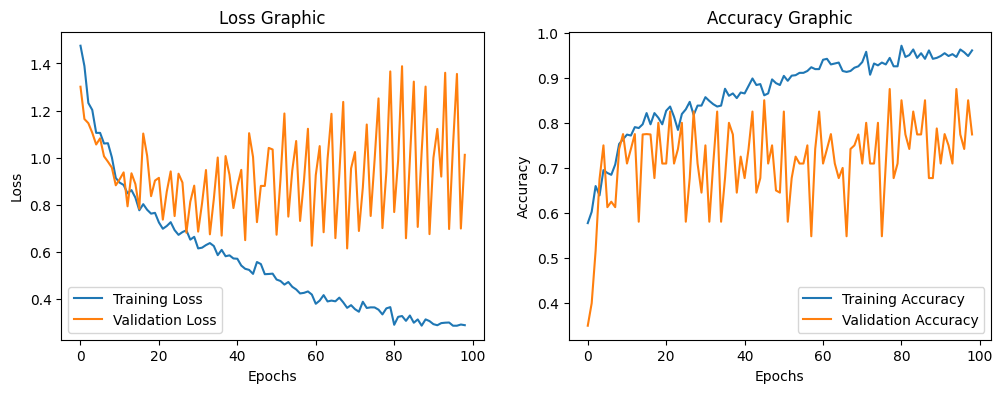

In [36]:
# Plotando o histórico de treinamento após o treinamento
met_vil.plot_training_history(history, f"{results_dir}")

### PREDIÇÃO TREINO

In [37]:
# # Crie uma pasta específica para esta saída massiva
# pdf_reports_dir = os.path.join(results_dir, "relatorios_axiais_treino")

# # Chame a nova função
# met_vil.generate_axial_pdf_reports(
#     model=model,
#     images=train_images,
#     true_labels_onehot=train_labels,
#     class_names=adni_class_names,
#     output_dir=pdf_reports_dir,
#     max_samples=2648
# )

### PREDIÇÃO VALIDAÇÃO

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
              precision    recall  f1-score   support

           0       0.91      0.81      0.86        26
           1       0.72      0.87      0.79        15

    accuracy                           0.83        41
   macro avg       0.82      0.84      0.82        41
weighted avg       0.84      0.83      0.83        41



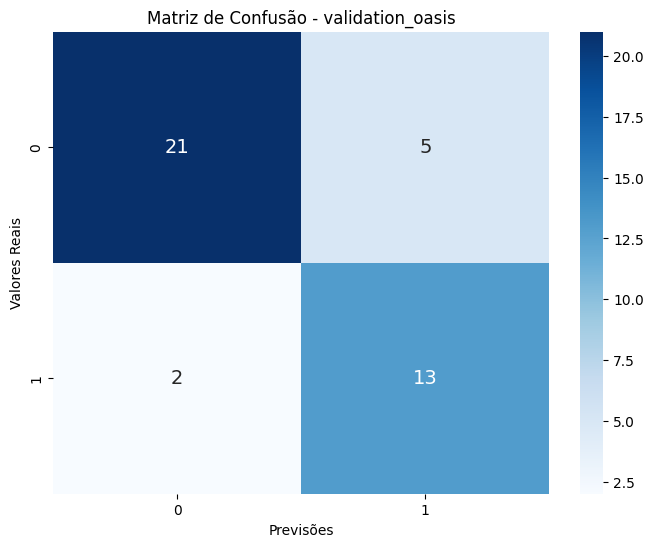

In [38]:
# Realizar predições para dados do conjunto validação
val_pred_labels, val_true_labels, val_pred = met_vil.get_predictions(val_images, val_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(val_true_labels, val_pred_labels, results_dir, 'validation_oasis')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(val_true_labels, val_pred_labels, results_dir, 'validation_oasis', used_class_names)

# Criar pdf com predições
val_pdf_path = os.path.join(results_dir, "validation_oasis_predictions.pdf")
met_vil.create_pdf(val_paths, val_images, val_true_labels, val_pred_labels, val_pred, val_pdf_path, used_class_names)

### PREDIÇÃO TESTE

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
              precision    recall  f1-score   support

           0       0.67      0.86      0.75        14
           1       0.80      0.57      0.67        14

    accuracy                           0.71        28
   macro avg       0.73      0.71      0.71        28
weighted avg       0.73      0.71      0.71        28



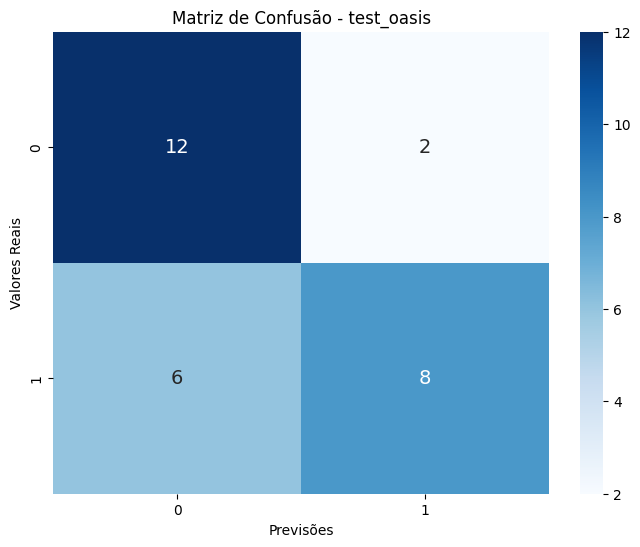

In [39]:
# Realizar predições para dados do conjunto validação
test_pred_labels, test_true_labels, test_pred = met_vil.get_predictions(test_images, test_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(test_true_labels, test_pred_labels, results_dir, 'test_oasis')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(test_true_labels, test_pred_labels, results_dir, 'test_oasis', used_class_names)

# Criar pdf com predições
test_pdf_path = os.path.join(results_dir, "test_oasis_predictions.pdf")
met_vil.create_pdf(test_paths, test_images, test_true_labels, test_pred_labels, test_pred, test_pdf_path, used_class_names)